In [1]:
from sklearn import datasets
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Feature Selection using Lasso


sabsa important feature ko rakta ha baki sara feature ka jo coeficent ha example $B_0,B_1,B_3$  other coeffiecent ha value ko zero kar deta ha  

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],test_size=0.2,random_state=45)

In [17]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [ ]:
# scale the Data 
from sklearn.preprocessing import StandardScaler

cols = X_train.columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled,columns=cols)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=cols)

In [19]:
X_train_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.134674,0.628533,0.756483,0.337582,-0.693725,0.061850,-0.132675,-0.957464
1,1.787682,1.849086,0.055456,-1.270161,-0.693725,0.400139,-0.839805,0.320542
2,-0.842438,-0.238701,-0.144838,0.955944,1.025676,0.776015,-0.569700,-1.042665
3,-0.550203,-1.298655,-0.445278,0.090237,-0.693725,-0.527023,-0.566665,-0.701863
4,0.034269,0.114616,0.556189,-1.270161,-0.693725,0.049321,0.179919,-0.531462
...,...,...,...,...,...,...,...,...
609,0.034269,-0.302941,0.456043,1.203289,-0.693725,0.938895,-0.730549,0.405743
610,-0.842438,-0.945337,-0.345131,0.275745,-0.341248,-1.554418,0.016035,-0.701863
611,-0.842438,-1.073816,0.456043,0.523090,-0.040353,0.011733,-0.339048,-0.361061
612,0.034269,-1.009577,-3.449679,-1.270161,-0.693725,-0.489435,0.404501,-0.190660


In [33]:
X_test_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.326504,1.174570,0.756483,1.265126,1.111646,0.938895,-0.248001,-0.361061
1,-0.842438,-0.656259,-0.946011,-0.342617,-0.384233,-0.965545,0.149570,-0.616663
2,-1.134674,-0.399300,0.956776,0.584927,-0.693725,0.074379,1.148049,0.405743
3,0.326504,0.821252,0.305823,-1.270161,-0.693725,-0.251380,-0.129640,-0.446262
4,-0.842438,-0.302941,0.556189,1.512471,0.441079,0.362551,-0.788212,-0.787063
...,...,...,...,...,...,...,...,...
149,1.787682,0.018257,-0.044691,-1.270161,-0.693725,-0.088500,-0.663781,0.661344
150,-0.842438,-0.784738,0.055456,1.203289,-0.693725,0.776015,-0.785177,-0.275861
151,2.956625,-0.688379,0.456043,0.275745,0.888124,0.588077,-0.196408,1.087347
152,0.910975,1.816966,0.756483,-1.270161,-0.693725,1.001541,-0.442234,0.661344


In [30]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled,y_train)

Lasso(alpha=0.1)

In [31]:
lasso.coef_

array([0.        , 0.127864  , 0.        , 0.        , 0.        ,
       0.01473879, 0.        , 0.        ])

<Axes: >

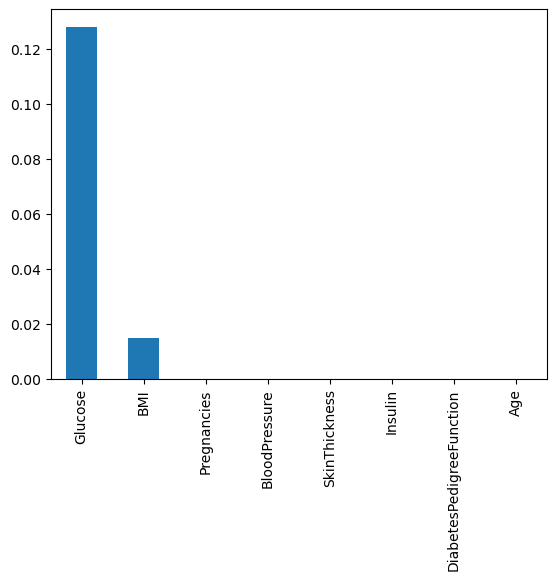

In [32]:
import matplotlib.pyplot as plt
import numpy as np

x = pd.Series(np.abs(lasso.coef_),index=cols)

x.sort_values(ascending=False).plot(kind='bar')

# Feature Selection using Decesion Treee

## import dataset

In [ ]:
# import the same dataset
from sklearn import datasets
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

df.head()

## train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],test_size=0.2,random_state=1)

In [34]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [36]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
727,0,141,84,26,0,32.4,0.433,22
327,10,179,70,0,0,35.1,0.200,37
721,1,114,66,36,200,38.1,0.289,21
210,2,81,60,22,0,27.7,0.290,25
683,4,125,80,0,0,32.3,0.536,27
...,...,...,...,...,...,...,...,...
725,4,112,78,40,0,39.4,0.236,38
607,1,92,62,25,41,19.5,0.482,25
544,1,88,78,29,76,32.0,0.365,29
643,4,90,0,0,0,28.0,0.610,31


## fit model 

In [47]:
from pandas.core.common import random_state
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [48]:
dt.feature_importances_

array([0.04998822, 0.32336761, 0.05337282, 0.0398696 , 0.06226017,
       0.17235013, 0.18136431, 0.11742714])

<Axes: >

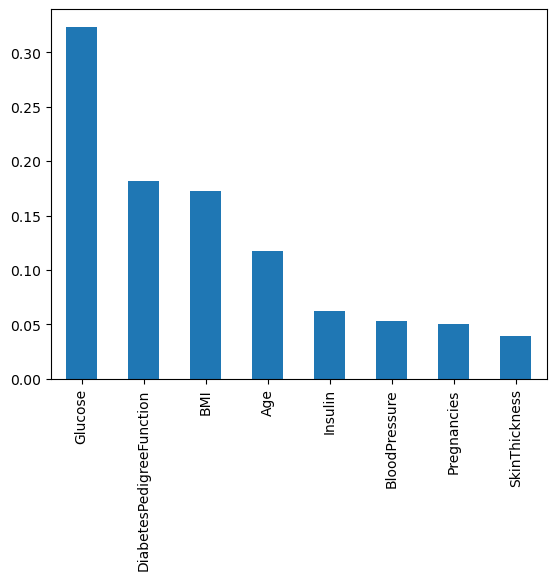

In [49]:
x = pd.Series(np.abs(dt.feature_importances_),index = cols)

x.sort_values(ascending=False).plot(kind = 'bar')

## using random forest 

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

RandomForestClassifier()

In [51]:
rf.feature_importances_

array([0.08191138, 0.25654738, 0.08405162, 0.07701128, 0.06590665,
       0.17319232, 0.13482728, 0.1265521 ])

<Axes: >

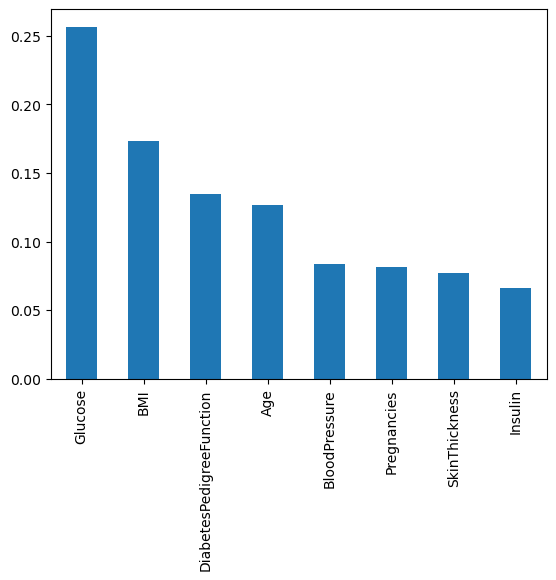

In [52]:
x = pd.Series(np.abs(rf.feature_importances_),index = cols)

x.sort_values(ascending=False).plot(kind = 'bar')

# SelectFromModel
it is a formal way to do Embeded methods 

In [ ]:
# use the same imported data and train test split then 

In [54]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

In [55]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(model, threshold='mean')

In [56]:
sfm.fit(X_train,y_train)

SelectFromModel(estimator=DecisionTreeClassifier(), threshold='mean')

In [57]:
sfm.get_support(indices=True)

array([1, 5, 7], dtype=int64)

In [59]:
sfm.feature_names_in_[sfm.get_support(indices=True)]

array(['Glucose', 'BMI', 'Age'], dtype=object)

In [60]:
X_train_trans = sfm.transform(X_train)

X_train_trans = pd.DataFrame(X_train_trans,columns=sfm.feature_names_in_[sfm.get_support(indices=True)])

X_train_trans

,Glucose,BMI,Age
0,145.0,37.9,40.0
1,129.0,41.2,38.0
2,102.0,37.2,45.0
3,120.0,25.0,64.0
4,120.0,39.7,29.0
...,...,...,...
609,157.0,39.4,30.0
610,187.0,33.9,34.0
611,126.0,43.4,42.0
612,171.0,43.6,26.0


# Recursive Feature Eliminiation

In [62]:
import seaborn as sns
df = sns.load_dataset(name='iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [70]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X,y)

RandomForestClassifier()

In [72]:
rf.feature_importances_

array([0.08782286, 0.02487154, 0.47461222, 0.41269339])

In [79]:
df.columns.to_flat_index

<bound method Index.to_flat_index of Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')>

array(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'], dtype=object)

In [89]:
# sabsa kam importance ha 2 wala columns ka 
pd.Series(data= rf.feature_importances_,  index=X.columns)

sepal_length    0.087823
sepal_width     0.024872
petal_length    0.474612
petal_width     0.412693
dtype: float64

In [95]:
pd.Series(data= np.round(a=rf.feature_importances_,decimals=2) * 100,  index=X.columns)


sepal_length     9.0
sepal_width      2.0
petal_length    47.0
petal_width     41.0
dtype: float64

In [ ]:
# so sepal_width ki sabsa kam weightage ha we drop it 

In [98]:
X.drop(columns='sepal_width',inplace=True)

In [99]:
X.head()

,sepal_length,petal_length,petal_width
0,5.1,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,0.2
4,5.0,1.4,0.2


In [ ]:
# now we repeat the whole step 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X,y)

# check the feature importance of each column
pd.Series(data= np.round(a=rf.feature_importances_,decimals=2) * 100,  index=X.columns)


sepal_length    19.0
petal_length    39.0
petal_width     42.0
dtype: float64

In [ ]:
# we drop the sepla_lenght colusmn
X.drop(columns='sepal_length',inplace=True)

In [104]:
X.head()

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [105]:
# now repeat the process agian 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X,y)

# check the feature importance of it
pd.Series(data= np.round(a=rf.feature_importances_,decimals=2) * 100,  index=X.columns)


petal_length    51.0
petal_width     49.0
dtype: float64

In [107]:
# drop the column petal width
X.drop(columns='petal_width',inplace=True)

In [ ]:
X
# this is our final column result 

,petal_length
0,1.4
1,1.4
2,1.3
3,1.5
4,1.4
...,...
145,5.2
146,5.0
147,5.2
148,5.4


# Sklearn RFE

In [3]:
# import libraries 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# load iris dataset
df = sns.load_dataset('iris')

# Separate features and target varibles
X = df.drop('species',axis=1)
y = df['species']


# Intialise Random forest classifer
model = RandomForestClassifier()


# Intialise RFE
rfe = RFE(estimator=model,n_features_to_select=1) # matlab last ma ek feature hon chaya

# fit RFE
rfe.fit(X,y)

# Print the ranking
ranking = rfe.ranking_
print("Feature ranking:")

for i, feature in enumerate(X.columns):
    print(f"{feature}: {ranking[i]}")


Feature ranking:
sepal_length: 3
sepal_width: 4
petal_length: 2
petal_width: 1


In [2]:
rfe.ranking_

array([3, 4, 1, 2])

sklearn ma ek aor rfe ha jisma step = 1 yani ek column chota ga vo apko layega answer